In [1]:
# ===================== 【1. 自定义配置 - 仅修改这里】 =====================
WSP_PATH = "/public/users/xueyupeng/VZV/lvzhu/20260129/separate/20260129_separate.wsp"       # FlowJo .wsp 文件路径
FCS_PATH = "/public/users/xueyupeng/VZV/lvzhu/20260129/separate/A004-V0_20260129-1_1-3.fcs"        # 对应 .fcs 数据路径
B_CELL_GATE_NAME = "B"           # FlowJo中B细胞门的准确名称
X_CHANNEL = "CXCL10_163Dy"                     # 分群用横坐标通道
Y_CHANNEL = "CD19_174Yb"                    # 展示用纵坐标通道

通道名称：
0 CD45-1_106Cd
1 CD45-2_110Cd
2 CD45-3_111Cd
3 CD8_112Cd
4 CD3_113In
5 CD45-4_114Cd
6 CD4_115In
7 CD45-5_116Cd
8 CD57_139La
9 CD56_141Pr
10 IgD_142Nd
11 IFN-a_144Nd
12 CXCL9_146Nd
13 CD86_147Sm
14 H3K27ac_148Nd
15 IL-1b_149Sm
16 4E-BP1_150Nd
17 pS6_151Eu
18 CCR2_152Sm
19 TNF-a_153Eu
20 IL-4_154Sm
21 CD14_155Gd
22 CASP-8_156Gd
23 TCR-gd_158Gd
24 CD38_159Tb
25 CD27_160Gd
26 CD123_161Dy
27 Ki-67_162Dy
28 CXCL10_163Dy
29 Arginase-1_164Dy
30 IL-6_165Ho
31 MCP-1_166Er
32 CD69_167Er
33 STC1_168Er
34 GZMB_169Tm
35 CD45RA_170Er
36 HLA-DR_171Yb
37 IFN-g_172Yb
38 CD11c_173Yb
39 CD19_174Yb
40 pSTAT1_175Lu
41 pSTAT3_176Yb
42 DNA1_191Ir
43 DNA2_193Ir
44 LIVE_198Pt
45 CD16_209Bi
46 CSR
47 Center
48 Event_Length
49 Offset
50 Residual
51 Time


/public/users/xueyupeng/.conda/envs/cytof/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 28857 (\N{CJK UNIFIED IDEOGRAPH-70B9}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/public/users/xueyupeng/.conda/envs/cytof/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20987 (\N{CJK UNIFIED IDEOGRAPH-51FB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/public/users/xueyupeng/.conda/envs/cytof/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20219 (\N{CJK UNIFIED IDEOGRAPH-4EFB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/public/users/xueyupeng/.conda/envs/cytof/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24847 (\N{CJK UNIFIED IDEOGRAPH-610F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/public/users/xueyupeng/.conda/envs/cytof/lib/python

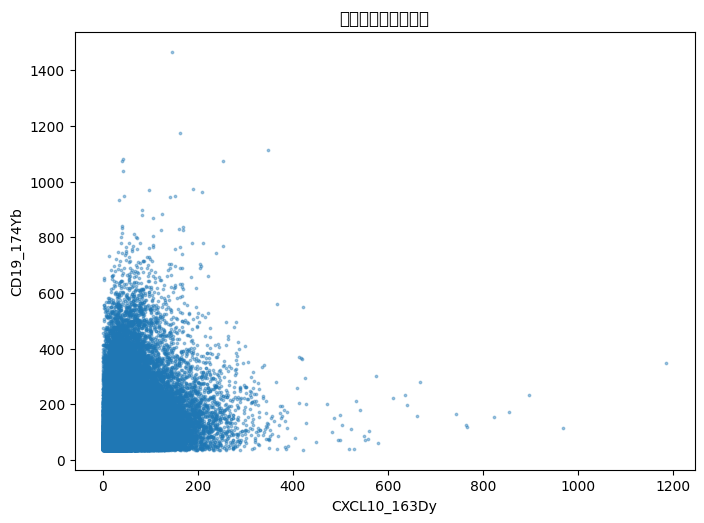

In [9]:
"""
交互式读取 FCS 文件 + 二维散点图 + 鼠标点击设阈值 + 自动统计阴阳比例

依赖安装：
pip install flowio matplotlib pandas numpy

如果你更习惯 FlowCal，也可改成：
pip install FlowCal
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.widgets import Button
from flowio import FlowData

# ===============================
# 1. 读取 FCS 文件
# ===============================
fcs_file = "/public/users/xueyupeng/VZV/lvzhu/subtype_raw/B/A004-V0_20260129-1_1-3.fcs"   # 修改成你的文件名

fd = FlowData(fcs_file)

# 原始数据 reshape
data = np.array(fd.events).reshape(fd.event_count, fd.channel_count)

# 通道名
channels = [fd.channels[i + 1]["pns"] for i in range(fd.channel_count)]

df = pd.DataFrame(data, columns=channels)

print("通道名称：")
for i, ch in enumerate(channels):
    print(i, ch)


# ===============================
# 2. 指定绘图通道
# ===============================
x_channel = "CXCL10_163Dy"   # 改成你要分析的X轴通道
y_channel = "CD19_174Yb"    # 改成Y轴通道

x = df[x_channel].values
y = df[y_channel].values


# ===============================
# 3. 绘图
# ===============================
fig, ax = plt.subplots(figsize=(8, 6))
plt.subplots_adjust(bottom=0.15)

sc = ax.scatter(x, y, s=3, alpha=0.4)

ax.set_xlabel(x_channel)
ax.set_ylabel(y_channel)
ax.set_title("点击任意点设定阈值")

threshold_line = None
text_box = None


# ===============================
# 4. 点击事件
# ===============================
def onclick(event):
    global threshold_line, text_box

    if event.inaxes != ax:
        return

    threshold = event.xdata

    # 删除旧线
    if threshold_line:
        threshold_line.remove()

    if text_box:
        text_box.remove()

    # 画阈值线
    threshold_line = ax.axvline(
        x=threshold,
        color="red",
        linestyle="--",
        linewidth=2
    )

    # 阴阳划分
    negative = np.sum(x < threshold)
    positive = np.sum(x >= threshold)
    total = len(x)

    neg_ratio = negative / total * 100
    pos_ratio = positive / total * 100

    result = (
        f"Threshold = {threshold:.2f}\n"
        f"Negative: {negative} ({neg_ratio:.2f}%)\n"
        f"Positive: {positive} ({pos_ratio:.2f}%)"
    )

    print(result)

    # 图上显示
    text_box = ax.text(
        0.02, 0.98,
        result,
        transform=ax.transAxes,
        verticalalignment='top',
        bbox=dict(boxstyle="round", facecolor="white")
    )

    fig.canvas.draw()


cid = fig.canvas.mpl_connect('button_press_event', onclick)

plt.show()



可用通道：
['CD45-1_106Cd', 'CD45-2_110Cd', 'CD45-3_111Cd', 'CD8_112Cd', 'CD3_113In', 'CD45-4_114Cd', 'CD4_115In', 'CD45-5_116Cd', 'CD57_139La', 'CD56_141Pr', 'IgD_142Nd', 'IFN-a_144Nd', 'CXCL9_146Nd', 'CD86_147Sm', 'H3K27ac_148Nd', 'IL-1b_149Sm', '4E-BP1_150Nd', 'pS6_151Eu', 'CCR2_152Sm', 'TNF-a_153Eu', 'IL-4_154Sm', 'CD14_155Gd', 'CASP-8_156Gd', 'TCR-gd_158Gd', 'CD38_159Tb', 'CD27_160Gd', 'CD123_161Dy', 'Ki-67_162Dy', 'CXCL10_163Dy', 'Arginase-1_164Dy', 'IL-6_165Ho', 'MCP-1_166Er', 'CD69_167Er', 'STC1_168Er', 'GZMB_169Tm', 'CD45RA_170Er', 'HLA-DR_171Yb', 'IFN-g_172Yb', 'CD11c_173Yb', 'CD19_174Yb', 'pSTAT1_175Lu', 'pSTAT3_176Yb', 'DNA1_191Ir', 'DNA2_193Ir', 'LIVE_198Pt', 'CD16_209Bi', 'CSR', 'Center', 'Event_Length', 'Offset', 'Residual', 'Time']


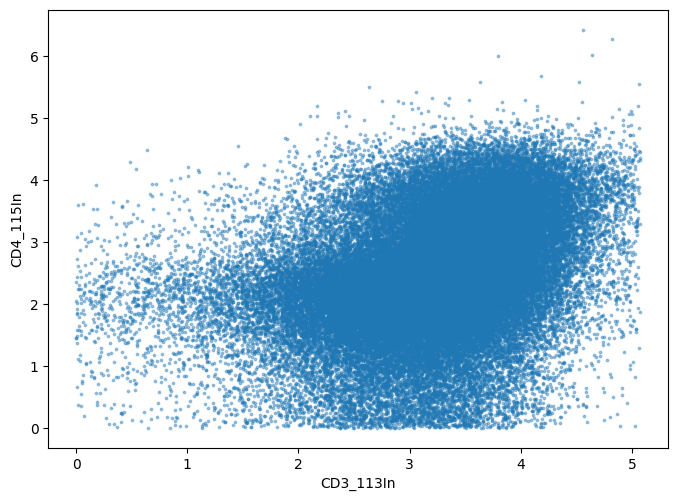

In [11]:
# ===============================
# 1. 读取 FCS 文件
# ===============================
fcs_file = "/public/users/xueyupeng/VZV/lvzhu/subtype_raw/B/A004-V0_20260129-1_1-3.fcs"   # ← 改这里

fd = FlowData(fcs_file)

data = np.array(fd.events).reshape(fd.event_count, fd.channel_count)

# 使用 marker 名（pns）
channels = []
for i in range(fd.channel_count):
    meta = fd.channels[i + 1]
    name = meta.get("pns", meta.get("pnn", f"Ch{i+1}"))
    channels.append(name)

df = pd.DataFrame(data, columns=channels)

print("可用通道：")
print(df.columns.tolist())


# ===============================
# 2. CyTOF标准变换（关键！）
# ===============================
df = np.arcsinh(df / 5)


# ===============================
# 3. 选择通道（自己改）
# ===============================
x_channel = "CD3_113In"
y_channel = "CD4_115In"

x = df[x_channel].values
y = df[y_channel].values


# ===============================
# 4. 绘图
# ===============================
fig, ax = plt.subplots(figsize=(8, 6))
plt.subplots_adjust(bottom=0.15)

ax.scatter(x, y, s=3, alpha=0.4)

ax.set_xlabel(x_channel)
ax.set_ylabel(y_channel)

threshold_line = None
text_box = None


# ===============================
# 5. 鼠标点击事件
# ===============================
def onclick(event):
    global threshold_line, text_box

    if event.inaxes != ax:
        return

    threshold = event.xdata

    # 删除旧元素
    if threshold_line:
        threshold_line.remove()
    if text_box:
        text_box.remove()

    # 画阈值线
    threshold_line = ax.axvline(
        x=threshold,
        linestyle="--",
        linewidth=2
    )

    # 计算比例
    negative = np.sum(x < threshold)
    positive = np.sum(x >= threshold)
    total = len(x)

    neg_ratio = negative / total * 100
    pos_ratio = positive / total * 100

    result = (
        f"Threshold = {threshold:.3f}\n"
        f"Negative: {negative} ({neg_ratio:.2f}%)\n"
        f"Positive: {positive} ({pos_ratio:.2f}%)"
    )

    print(result)

    # 图上显示
    text_box = ax.text(
        0.02, 0.98,
        result,
        transform=ax.transAxes,
        verticalalignment='top',
        bbox=dict(boxstyle="round", facecolor="white")
    )

    fig.canvas.draw()


fig.canvas.mpl_connect('button_press_event', onclick)

plt.show()

In [8]:
from flowio import FlowData

fd = FlowData("/public/users/xueyupeng/VZV/lvzhu/subtype_raw/B/A004-V0_20260129-1_1-3.fcs")

print(fd.channels)

{10: {'pnn': '141', 'pns': 'CD56_141Pr', 'pne': (0.0, 0.0), 'png': 1.0, 'pnr': 1.0}, 11: {'pnn': '142', 'pns': 'IgD_142Nd', 'pne': (0.0, 0.0), 'png': 1.0, 'pnr': 1.0}, 12: {'pnn': '144', 'pns': 'IFN-a_144Nd', 'pne': (0.0, 0.0), 'png': 1.0, 'pnr': 1.0}, 13: {'pnn': '146', 'pns': 'CXCL9_146Nd', 'pne': (0.0, 0.0), 'png': 1.0, 'pnr': 1.0}, 14: {'pnn': '147', 'pns': 'CD86_147Sm', 'pne': (0.0, 0.0), 'png': 1.0, 'pnr': 1.0}, 15: {'pnn': '148', 'pns': 'H3K27ac_148Nd', 'pne': (0.0, 0.0), 'png': 1.0, 'pnr': 1.0}, 16: {'pnn': '149', 'pns': 'IL-1b_149Sm', 'pne': (0.0, 0.0), 'png': 1.0, 'pnr': 1.0}, 17: {'pnn': '150', 'pns': '4E-BP1_150Nd', 'pne': (0.0, 0.0), 'png': 1.0, 'pnr': 1.0}, 18: {'pnn': '151', 'pns': 'pS6_151Eu', 'pne': (0.0, 0.0), 'png': 1.0, 'pnr': 1.0}, 19: {'pnn': '152', 'pns': 'CCR2_152Sm', 'pne': (0.0, 0.0), 'png': 1.0, 'pnr': 1.0}, 1: {'pnn': '106', 'pns': 'CD45-1_106Cd', 'pne': (0.0, 0.0), 'png': 1.0, 'pnr': 262144.0}, 20: {'pnn': '153', 'pns': 'TNF-a_153Eu', 'pne': (0.0, 0.0), 'pn